# PSD estimator bias-variance comparison

Empirical MSE / bias / variance of the raw estimators (Welch, lag-window,
multitaper) against their PSDebias fits, the fixed-mesh Dquad baseline
(debias arm) and wavelet thresholding (smoothing arm), on AR(4) and Matérn
processes. All statistics are computed in the log-spectrum domain against the
closed-form truth.

Inputs are the caches written by `scripts/generate_realisations.py`
(`debias` and `smooth` arms) and `scripts/wavelet_thresholding.py`.

In [15]:
import os

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from psdebias import (
    ar_spectrum,
    lag_window,
    matern_spectrum,
    multitaper,
    window_bandwidth,
)


import scienceplots  # noqa: F401
plt.style.use(['science', 'ieee'])

try:
    import scienceplots  # noqa: F401
    plt.style.use(['science', 'ieee'])
except ImportError:
    pass

# plt.rcParams['text.usetex'] = True

In [2]:
BASE = '../scripts/realisations'  # output of generate_realisations.py
FIGS = '../figs'

MS_WELCH = [2 ** i for i in range(3, 7)]  # Welch: segment counts
NW_DEBIAS = [3, 4, 6, 8]                  # lag-window / multitaper NW, debias arm
N_QUAD = { 'debiasing': 2 ** 11}  # quad-arm series lengths

# Lag truncations actually used, keyed by the NW the files are named after.
# These mirror `lags_quad` in generate_realisations.py and are NOT N // NW in
# the debias arm (2**11 // [3, 4, 8, 16] paired with NW = 3, 4, 6, 8).
LAGS_DEBIAS = dict(zip(NW_DEBIAS, 2 ** 11 // np.array([3, 4, 8, 16])))

# Sampler knot spacing per arm, for the mesh-vs-bandwidth diagnostic below.
KNOT_SPACING = {'debiasing': {'welch': 4, 'quad': 8},
                }
QUAD_WINDOW = {'debiasing': 'bartlett'}

AR4_POLY = np.array([1.0, -2.7607, 3.8106, -2.6535, 0.9238])
MATERN_ALPHA = 1.5
MATERN_LAMBDA = 0.1

## Shared helpers

One loader / stats / print / plot pipeline driven by a per-method config.
Adaptive CSVs hold `[E[#knots]] + mean_S(f) + std_S(f)` in linear scale (both
arms — smooth-mode draws are exponentiated inside the sampler), so every
stream is logged here before comparison.

In [3]:
def truth_spectrum(freqs, signal):
    if signal == 'ar4':
        return ar_spectrum(freqs, AR4_POLY, sd=1.0)
    return matern_spectrum(freqs, eta=1.0, alpha=MATERN_ALPHA, lmbda=MATERN_LAMBDA)


def load_results(cfg, ms, base_dir, signal):
    """Load one method's caches: raw estimates, adaptive CSVs, and (when the
    generating arm produced them) Dquad / wavelet stacks."""
    sim_dir = f"{base_dir}/{cfg['sim_subdir']}"

    value = np.array([np.load(f"{sim_dir}/{cfg['value'].format(m=m)}") for m in ms])
    adapt_raw = np.array([
        np.genfromtxt(f"{sim_dir}/{cfg['adapt'].format(m=m)}", delimiter=',')
        for m in ms
    ])

    n_freq = value.shape[-1]
    freqs = sp.fft.rfftfreq(2 * n_freq + 2, d=1.0)[1:-1]
    adapt = adapt_raw[..., 1:n_freq + 1]  # drop E[#knots]; ignore the std block

    try:
        dquad = [np.load(f"{sim_dir}/{cfg['dquad'].format(m=m)}") for m in ms]
    except FileNotFoundError:
        dquad = None

    try:
        wavelet = [np.load(f"{sim_dir}/{cfg['wavelet'].format(m=m)}") for m in ms]
    except FileNotFoundError:
        wavelet = None

    return {
        'value': value, 'adapt': adapt, 'dquad': dquad, 'wavelet': wavelet,
        'expected_knots': adapt_raw[..., 0], 'Truth': truth_spectrum(freqs, signal),
    }


def _stream_stats(stream, log_truth):
    """Per-setting list of (n_realisations, 3) arrays of [MSE, Bias, Var], plus
    the (kept, total) realisation counts.

    Kept ragged: the Dquad stacks can have fewer (even zero) surviving
    realisations per setting, unlike the always-full value/adapt/wavelet. Rows
    that are not strictly positive are dropped here — a debias-mode posterior
    mean can land marginally below zero, and one such row would otherwise turn
    the whole setting into NaN once logged and averaged."""
    out, counts = [], []
    for sim in stream:
        rows = np.asarray(sim).reshape(-1, log_truth.size)
        keep = np.all(rows > 0, axis=-1)
        counts.append((int(keep.sum()), len(rows)))
        diff = np.log(rows[keep]) - log_truth
        mse = np.mean(diff ** 2, axis=-1)
        bias = np.mean(diff, axis=-1)
        out.append(np.stack([mse, bias**2, mse - bias ** 2], axis=-1))
    return out, counts


def compute_stats(results):
    log_truth = np.log(results['Truth'])
    stats, counts = {}, {}
    for key in ('value', 'adapt', 'dquad', 'wavelet'):
        stream = results[key]
        if stream is None:
            stats[key] = counts[key] = None
            continue
        stats[key], counts[key] = _stream_stats(stream, log_truth)
    stats['counts'] = counts
    return stats


STREAM_LABELS = {'adapt': 'PSDebias', 'dquad': 'Dquad', 'wavelet': 'Wavelet Thresholding'}


def _safe_mean(x):
    return np.mean(x) if len(x) else np.nan


def _safe_std(x):
    return np.std(x) if len(x) else np.nan


def _mean_band_per_setting(stream_stats, col):
    means = np.array([_safe_mean(s[:, col]) for s in stream_stats])
    stds = np.array([_safe_std(s[:, col]) for s in stream_stats])
    return means, means - stds, means + stds


def print_ratios(stats, ms_labels):
    """Each stream's MSE / Bias^2 / Var relative to the raw estimator, over
    however many realisations that setting has, with the count as
    ``n=kept/drawn``. Read it: a Dquad ratio from 1 of 200 realisations is not
    the same claim as one from 200, and only the count says which it is."""
    counts = stats['counts']
    base_mse = np.array([_safe_mean(s[:, 0]) for s in stats['value']])
    base_bias2 = np.array([_safe_mean(s[:, 1] ** 2) for s in stats['value']])
    base_var = np.array([_safe_mean(s[:, 2]) for s in stats['value']])

    for key, label in STREAM_LABELS.items():
        stream = stats.get(key)
        if stream is None:
            continue
        mse = np.array([_safe_mean(s[:, 0]) for s in stream])
        bias2 = np.array([_safe_mean(s[:, 1] ** 2) for s in stream])
        var = np.array([_safe_mean(s[:, 2]) for s in stream])
        print(f"{label}:")
        for i, m in enumerate(ms_labels):
            print(f"  {m}: n={counts[key][i][0]}/{counts['value'][i][1]}, "
                  f"MSE: {mse[i] / base_mse[i]:.2f}, "
                  f"Bias^2: {bias2[i] / base_bias2[i]:.2f}, Var: {var[i] / base_var[i]:.2f}")


def plot_results(ms, stats, label, xlabel, xticklabels=None, fig_title=''):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    # Markers matter: a setting with no surviving realisation breaks the line,
    # and without them a point between two such gaps would draw nothing at all.
    marker = dict(marker='o', markersize=3)

    for col, title in enumerate([r'MSE', r'$\textrm{Bias}^2$', r'Var']):
        mean_v, lower_v, upper_v = _mean_band_per_setting(stats['value'], col)
        mean_a, lower_a, upper_a = _mean_band_per_setting(stats['adapt'], col)
        ax[col].plot(ms, mean_v, label=label, linestyle='dashed', **marker)
        ax[col].fill_between(ms, lower_v, upper_v, alpha=0.2)
        ax[col].plot(ms, mean_a, label='PSDebias', **marker)
        ax[col].fill_between(ms, lower_a, upper_a, alpha=0.2)

        for key in ('dquad', 'wavelet'):
            stream = stats.get(key)
            if stream is None:
                continue
            mean_s, lower_s, upper_s = _mean_band_per_setting(stream, col)
            ax[col].plot(ms, mean_s, label=STREAM_LABELS[key], **marker)
            ax[col].fill_between(ms, lower_s, upper_s, alpha=0.2)

        ax[col].legend()
        ax[col].set_title(title)
        ax[col].set_xticks(ms)
        ax[col].set_xlabel(xlabel)
        if xticklabels is not None:
            ax[col].set_xticklabels(xticklabels)

    fig.suptitle(fig_title)
    return fig, ax

## Method configurations

File layout and x-axis per estimator. Lag-window settings are keyed by NW on
disk but displayed by the lag truncation $\tau$ the file was actually generated
with, read from `LAGS_DEBIAS` / `LAGS_SMOOTH` (hence the reversed file list, so
the display axis ascends). Note $\tau \neq N/\mathrm{NW}$ in the debias arm —
the script pairs NW = 3, 4, 6, 8 with $\tau$ = 682, 512, 256, 128.

In [4]:
METHODS = {
    'Welch': {
        'slug': 'welch', 'sim_subdir': 'welch_sim',
        'value': 'welch/{m}.npy', 'adapt': 'adapt_welch/{m}.csv',
        'dquad': 'dwelch/{m}.npy', 'wavelet': 'welch_wavelet/{m}.npy',
        'xlabel': 'M',
        'xticklabels': [fr'$2^{{{int(np.log2(m))}}}$' for m in MS_WELCH],
        'file_ms': {'debiasing': MS_WELCH},
        'display_ms': {'debiasing': MS_WELCH},
    },
    'Lag-Window': {
        'slug': 'lag', 'sim_subdir': 'quad_sim',
        'value': 'lag-window/NW{m}.npy', 'adapt': 'adapt_lag/NW{m}.csv',
        'dquad': 'dlag/NW{m}.npy', 'wavelet': 'lag_wavelet/{m}.npy',
        'xlabel': r'$\tau$', 'xticklabels': None,
        'file_ms': { 'debiasing': NW_DEBIAS[::-1]},
        'display_ms': {
            'debiasing': [LAGS_DEBIAS[nw] for nw in NW_DEBIAS[::-1]],
        },
    },
    'Multitaper': {
        'slug': 'multi', 'sim_subdir': 'quad_sim',
        'value': 'multitaper/NW{m}.npy', 'adapt': 'adapt_multi/NW{m}.csv',
        'dquad': 'dmulti/NW{m}.npy', 'wavelet': 'multi_wavelet/{m}.npy',
        'xlabel': 'NW', 'xticklabels': None,
        'file_ms': { 'debiasing': NW_DEBIAS},
        'display_ms': {'debiasing': NW_DEBIAS},
    },
}

ARMS = { 'debiasing': 'bias'}  # dir suffix -> figure slug

SIGNALS = {
    'ar4': {'slug': 'ar4', 'title': 'AR4'},
    'matern': {'slug': 'mat', 'title': 'Matérn'},
}

## Run all comparisons

Every (estimator × arm × signal) combination; skips arms whose realisations
have not been generated yet.

=== Welch / AR4 / debiasing ===
PSDebias:
  8: n=200/200, MSE: 0.43, Bias^2: 0.22, Var: 0.55
  16: n=200/200, MSE: 0.32, Bias^2: 0.13, Var: 0.40
  32: n=200/200, MSE: 0.23, Bias^2: 0.08, Var: 0.30
  64: n=200/200, MSE: 0.19, Bias^2: 0.05, Var: 0.25
Dquad:
  8: n=101/200, MSE: 0.73, Bias^2: 0.41, Var: 0.91
  16: n=110/200, MSE: 0.53, Bias^2: 0.25, Var: 0.66
  32: n=119/200, MSE: 0.37, Bias^2: 0.14, Var: 0.46
  64: n=122/200, MSE: 0.30, Bias^2: 0.09, Var: 0.37


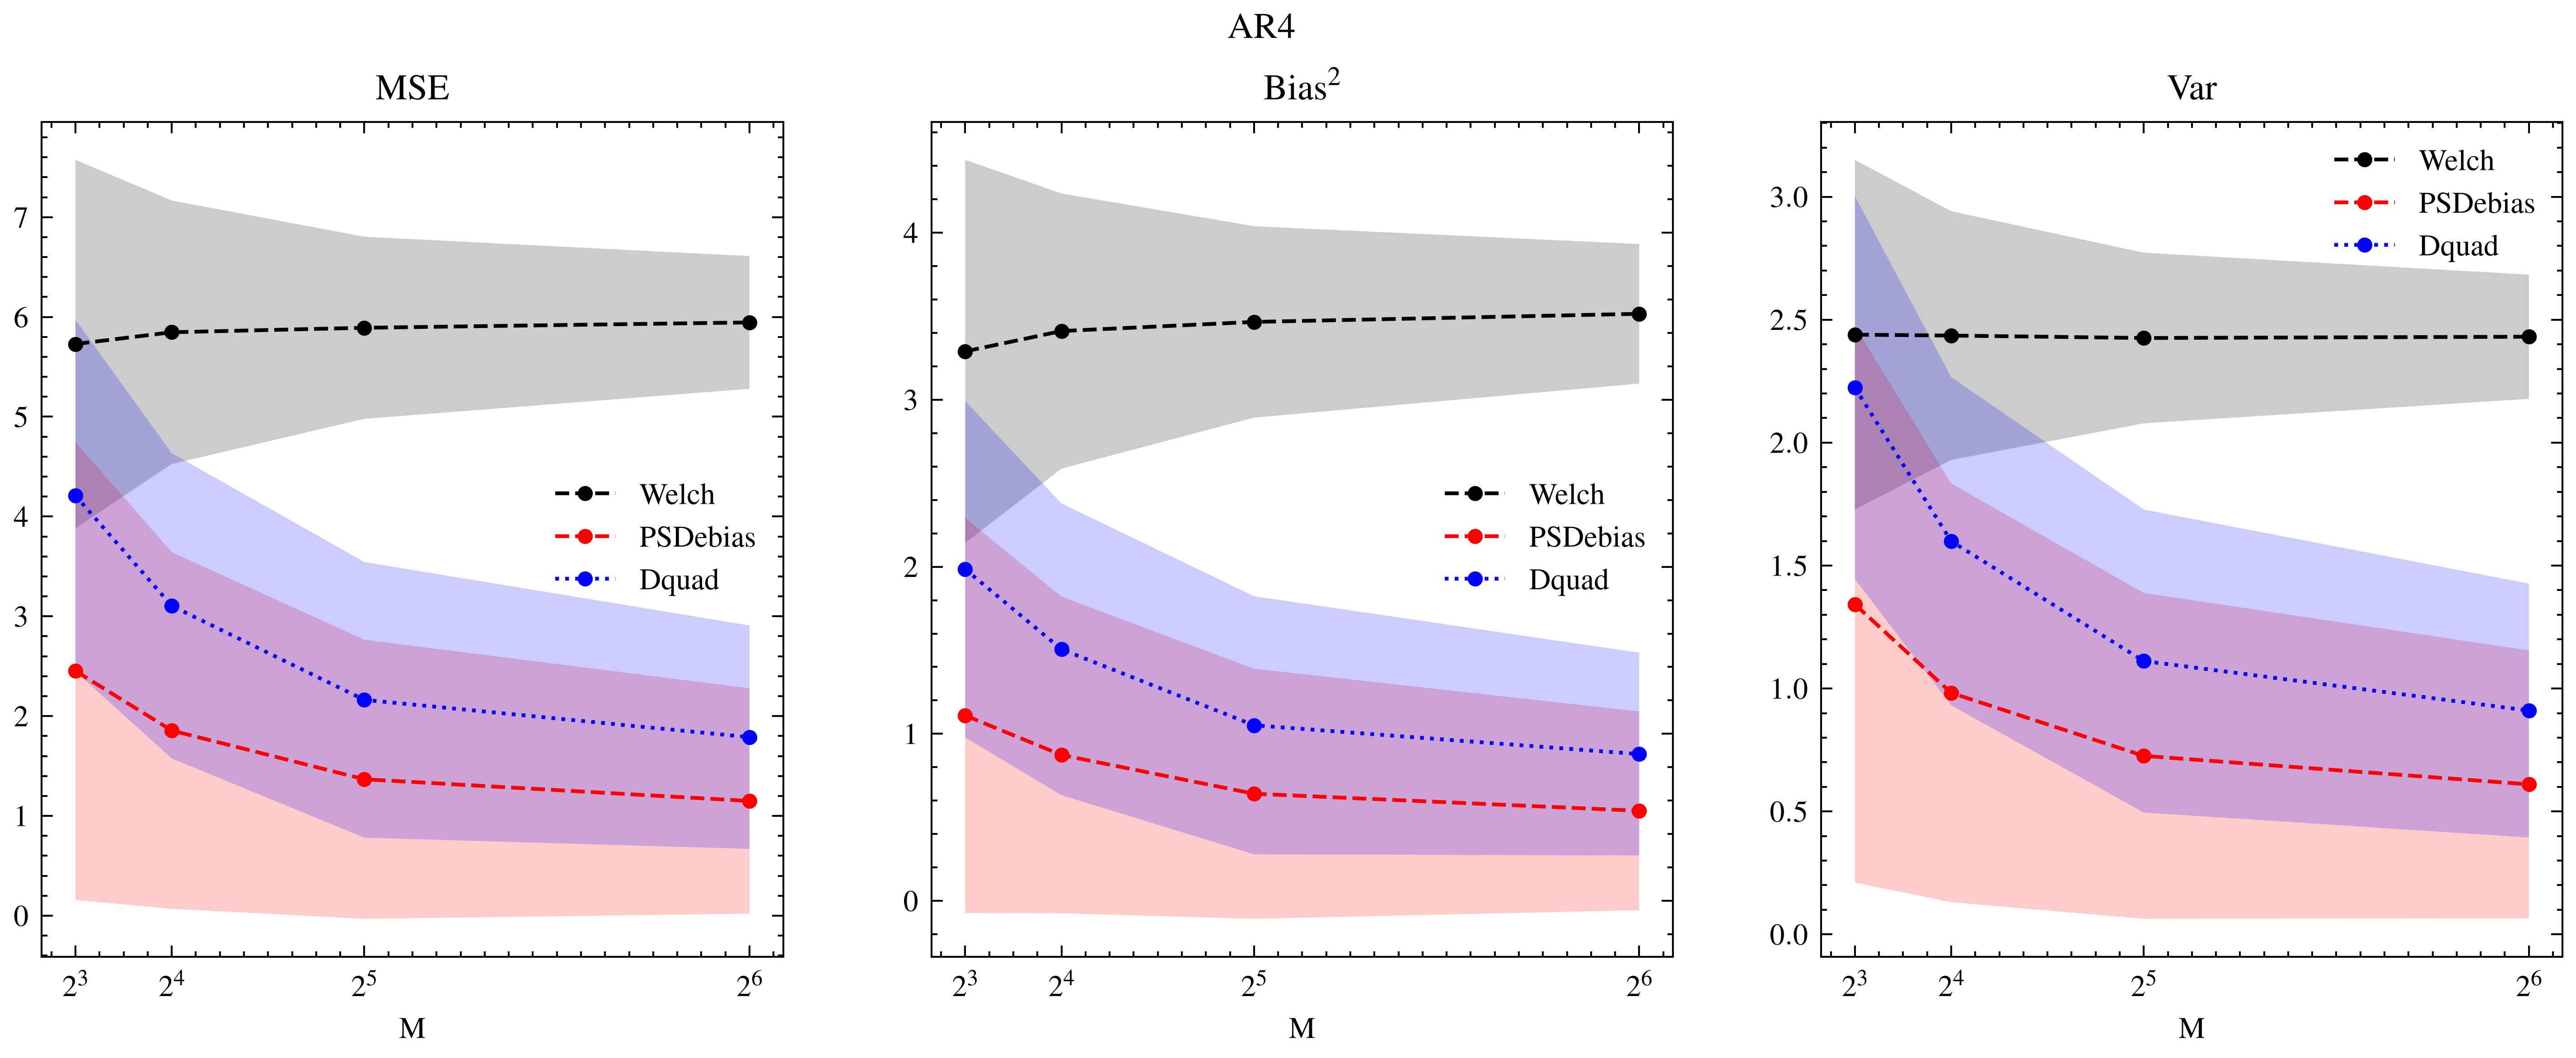

=== Welch / Matérn / debiasing ===
PSDebias:
  8: n=200/200, MSE: 0.33, Bias^2: 0.30, Var: 0.29
  16: n=200/200, MSE: 0.28, Bias^2: 0.01, Var: 0.37
  32: n=200/200, MSE: 0.33, Bias^2: 0.03, Var: 0.45
  64: n=200/200, MSE: 0.38, Bias^2: 0.06, Var: 0.51
Dquad:
  8: n=199/200, MSE: 0.56, Bias^2: 0.10, Var: 0.62
  16: n=200/200, MSE: 0.41, Bias^2: 0.02, Var: 0.55
  32: n=200/200, MSE: 0.40, Bias^2: 0.05, Var: 0.55
  64: n=200/200, MSE: 0.42, Bias^2: 0.07, Var: 0.56


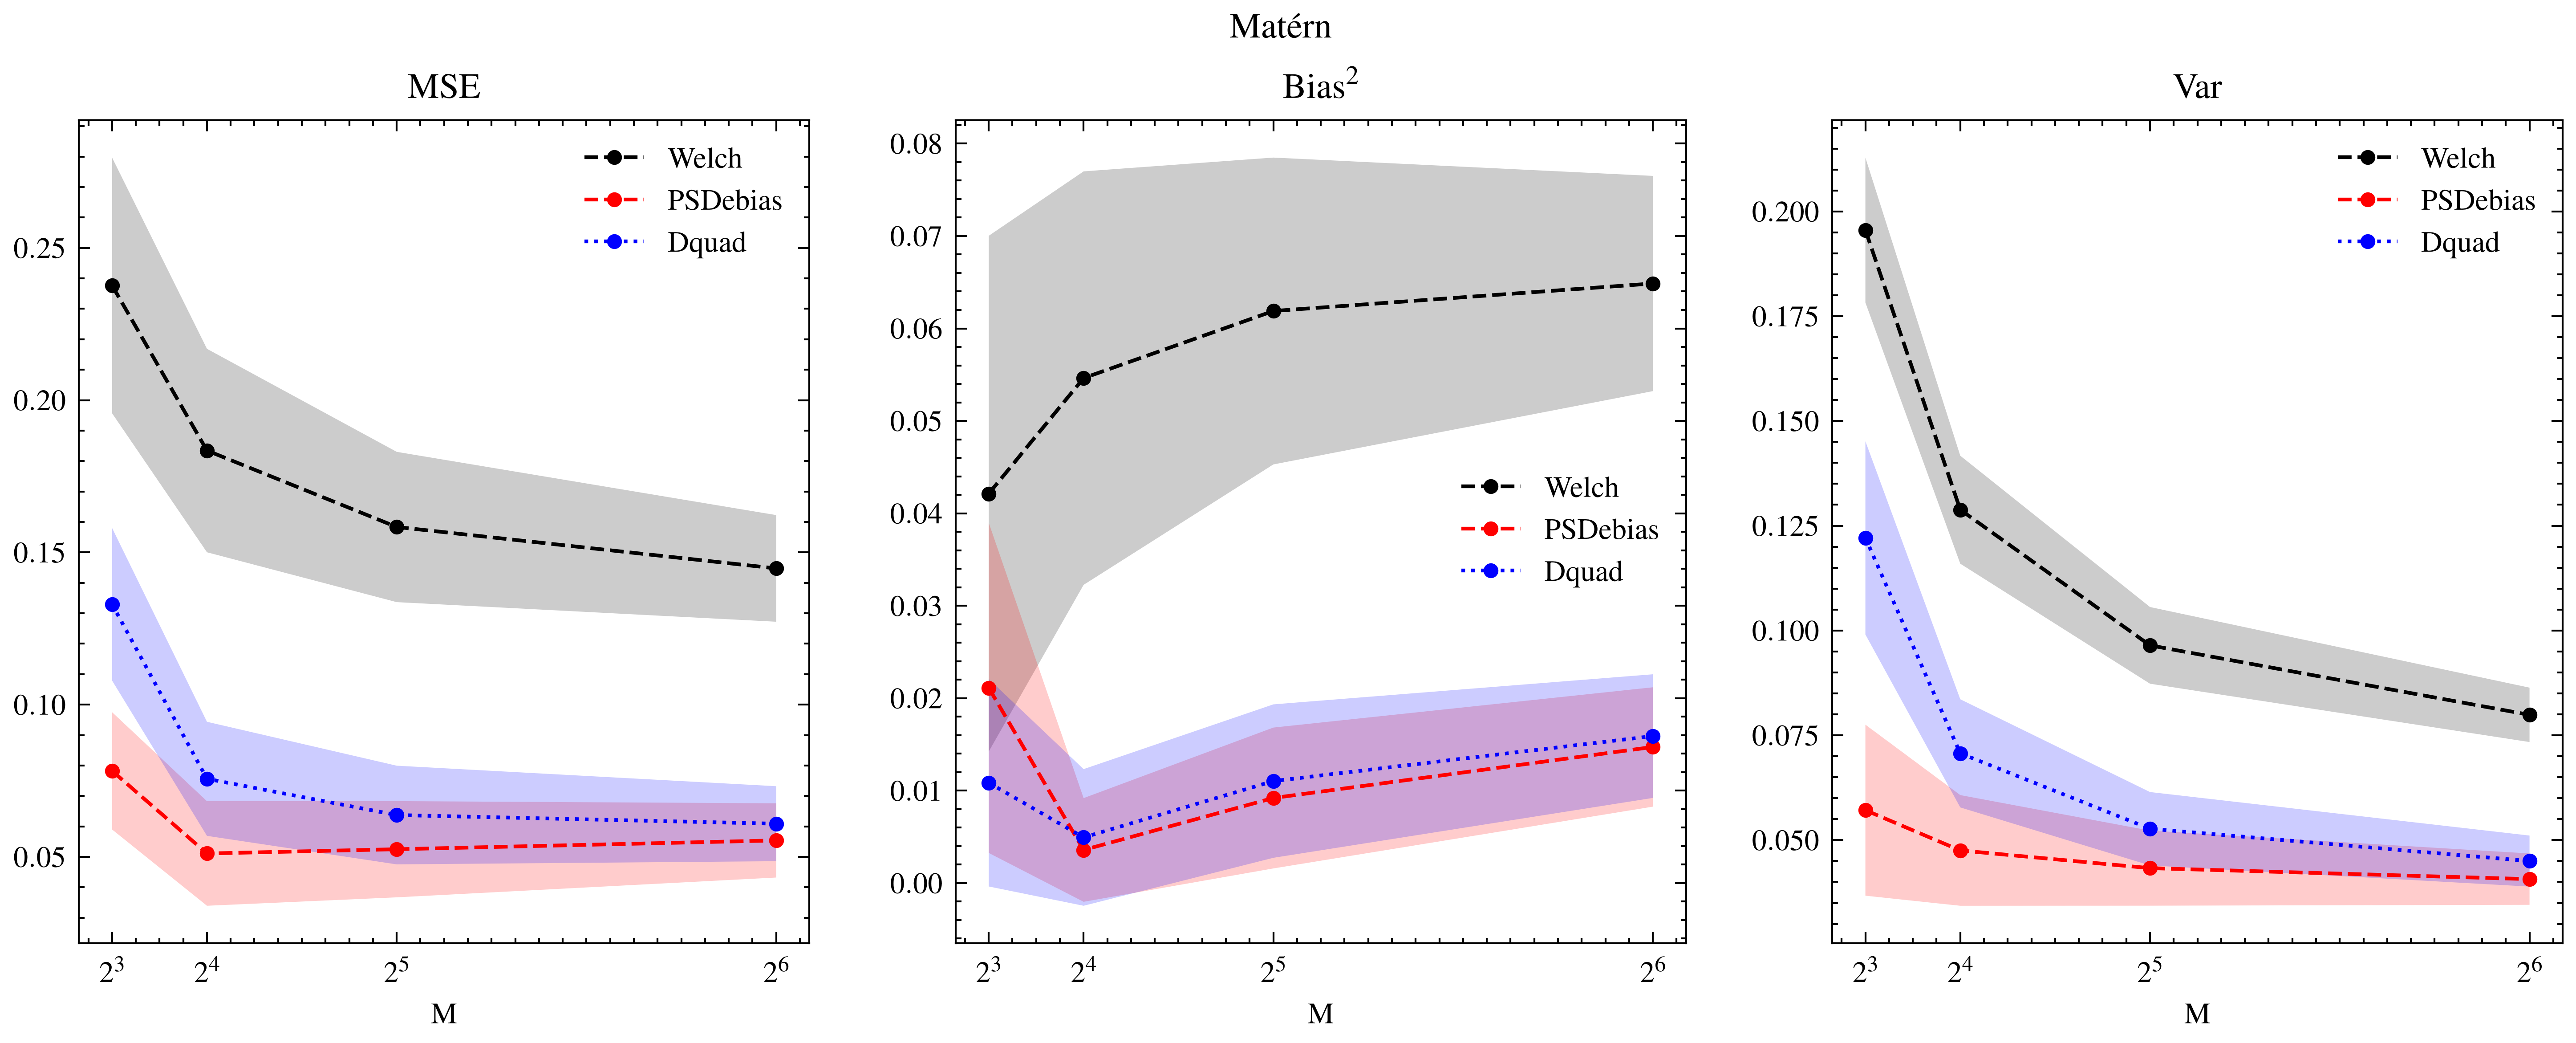

=== Lag-Window / AR4 / debiasing ===
PSDebias:
  128: n=200/200, MSE: 0.11, Bias^2: 0.01, Var: 0.19
  256: n=200/200, MSE: 0.17, Bias^2: 0.04, Var: 0.25
  512: n=200/200, MSE: 0.28, Bias^2: 0.09, Var: 0.38
  682: n=200/200, MSE: 0.33, Bias^2: 0.12, Var: 0.45
Dquad:
  128: n=0/200, MSE: nan, Bias^2: nan, Var: nan
  256: n=90/200, MSE: 0.31, Bias^2: 0.07, Var: 0.46
  512: n=140/200, MSE: 0.38, Bias^2: 0.13, Var: 0.52
  682: n=154/200, MSE: 0.41, Bias^2: 0.15, Var: 0.55


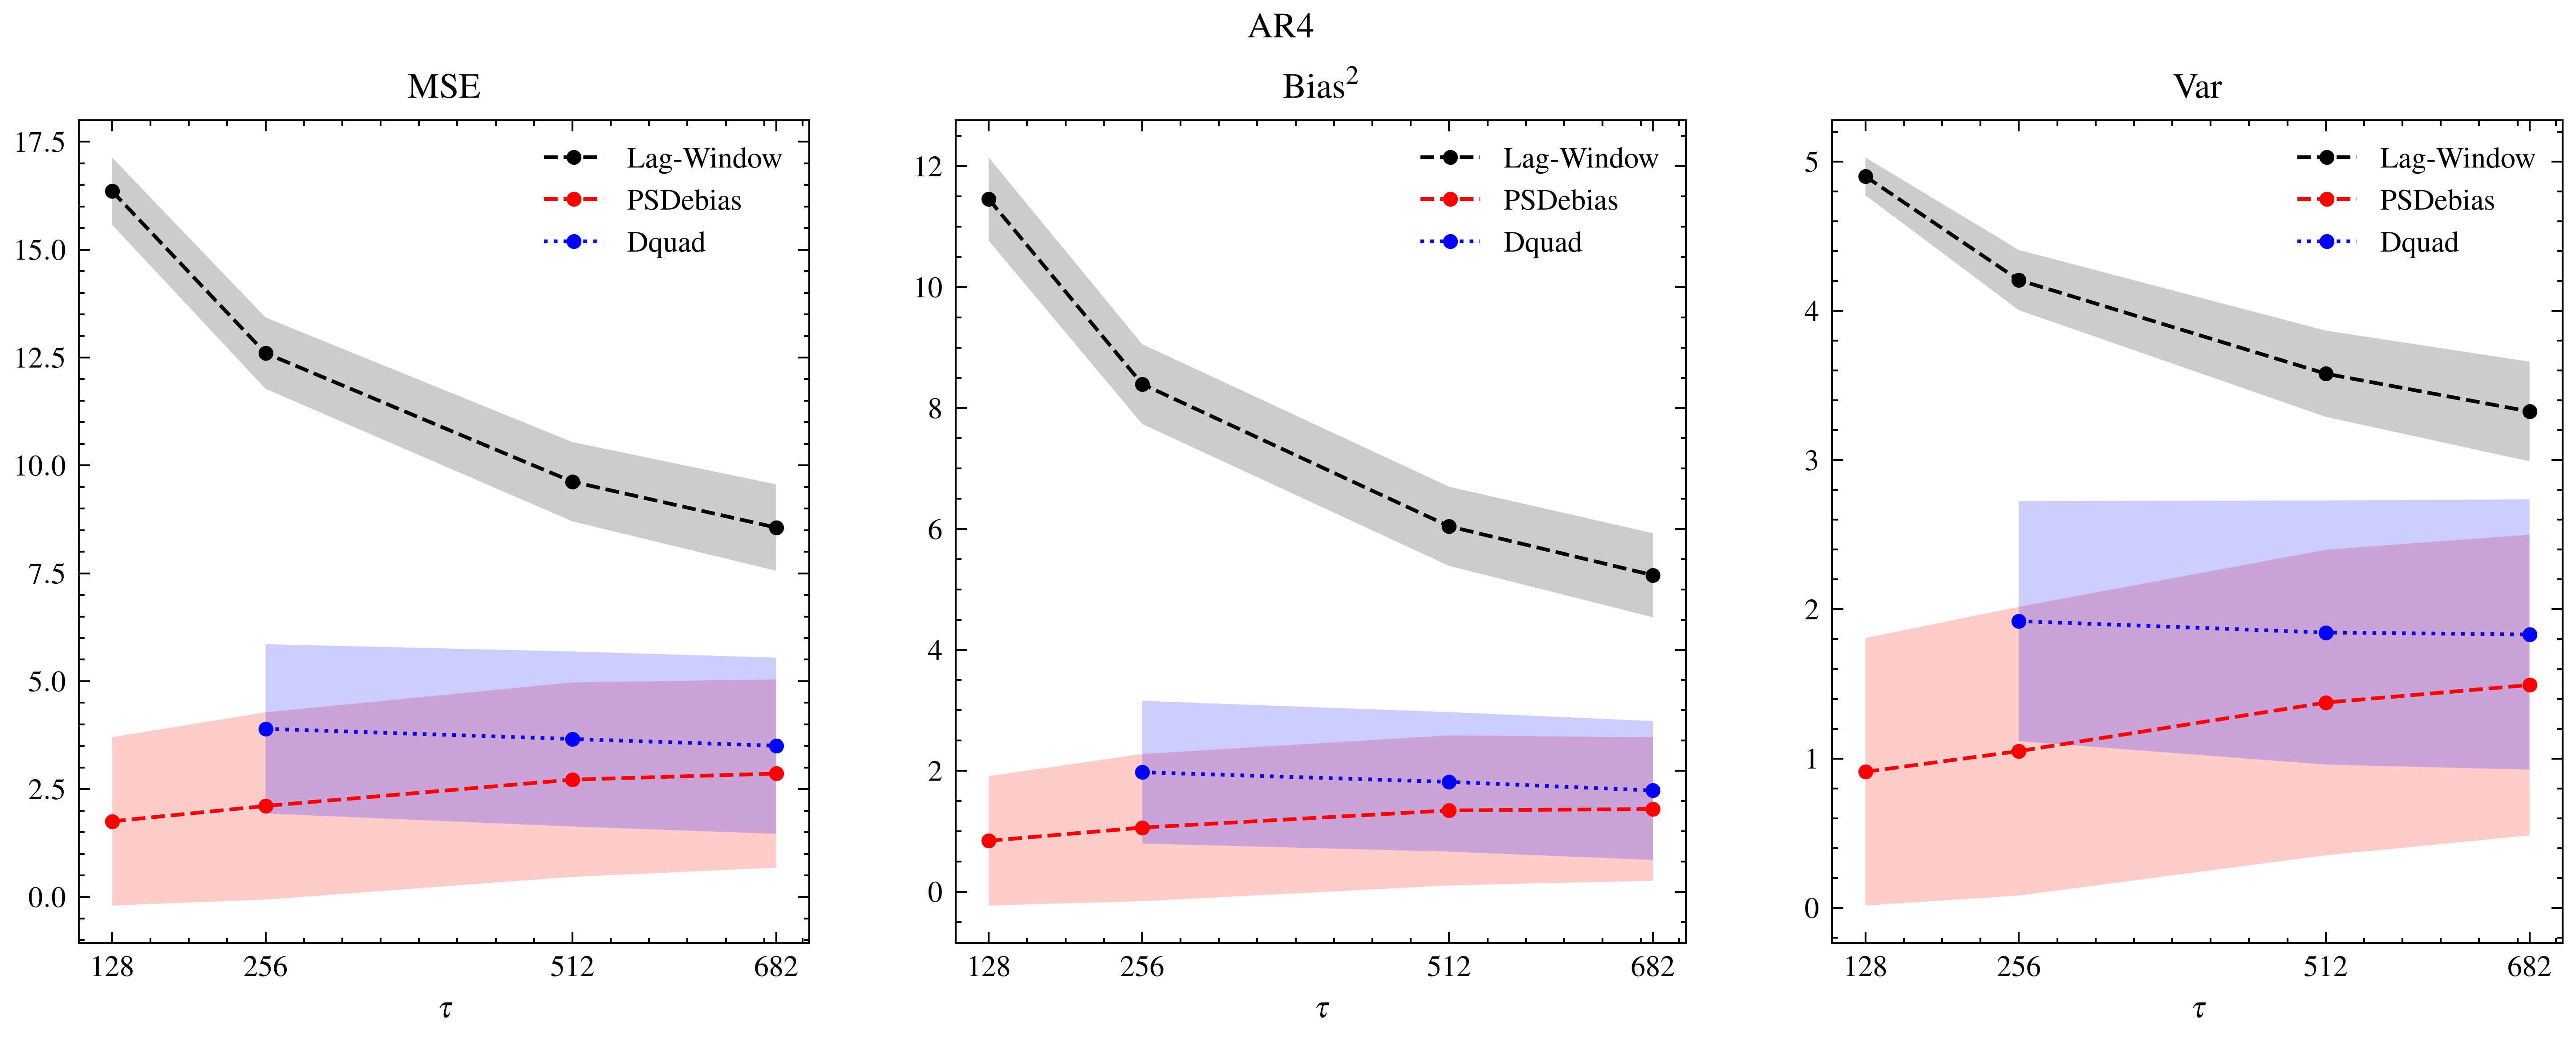

=== Lag-Window / Matérn / debiasing ===
PSDebias:
  128: n=200/200, MSE: 0.30, Bias^2: 0.00, Var: 0.98
  256: n=199/200, MSE: 0.43, Bias^2: 0.00, Var: 1.01
  512: n=200/200, MSE: 0.47, Bias^2: 0.01, Var: 0.72
  682: n=200/200, MSE: 0.43, Bias^2: 0.01, Var: 0.55
Dquad:
  128: n=1/200, MSE: 0.33, Bias^2: 0.00, Var: 1.02
  256: n=199/200, MSE: 0.45, Bias^2: 0.00, Var: 1.06
  512: n=200/200, MSE: 0.60, Bias^2: 0.01, Var: 0.94
  682: n=200/200, MSE: 0.65, Bias^2: 0.01, Var: 0.86


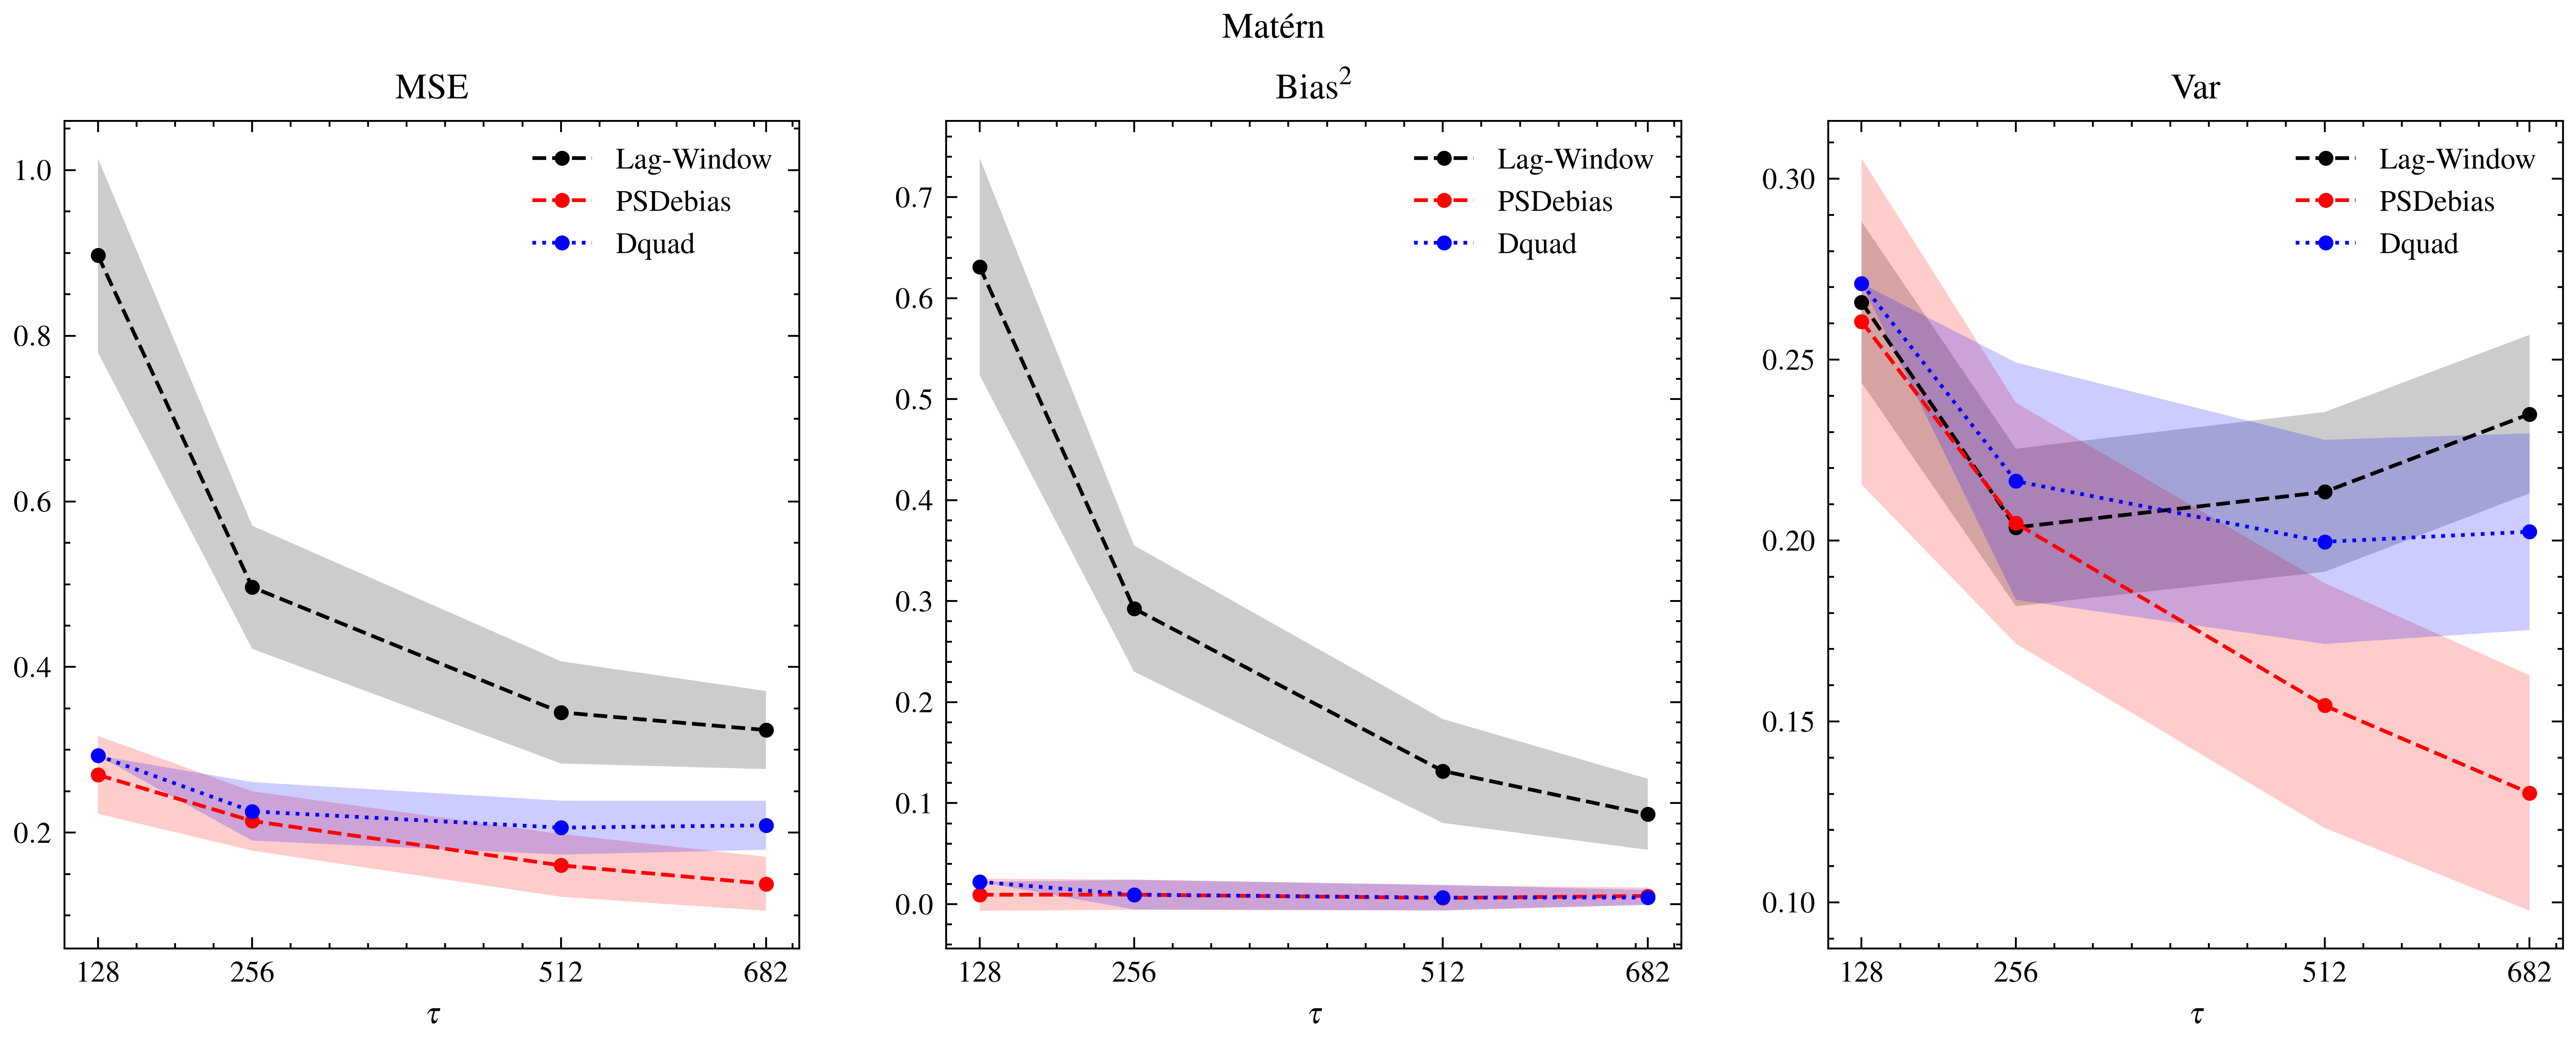

=== Multitaper / AR4 / debiasing ===
PSDebias:
  3: n=200/200, MSE: 0.79, Bias^2: 0.51, Var: 0.89
  4: n=200/200, MSE: 0.78, Bias^2: 0.50, Var: 0.91
  6: n=200/200, MSE: 0.74, Bias^2: 0.46, Var: 0.94
  8: n=200/200, MSE: 0.71, Bias^2: 0.40, Var: 0.94
Dquad:
  3: n=51/200, MSE: 1.45, Bias^2: 1.32, Var: 1.64
  4: n=45/200, MSE: 1.63, Bias^2: 1.69, Var: 1.77
  6: n=35/200, MSE: 1.79, Bias^2: 1.86, Var: 1.98
  8: n=6/200, MSE: 2.11, Bias^2: 2.43, Var: 2.40


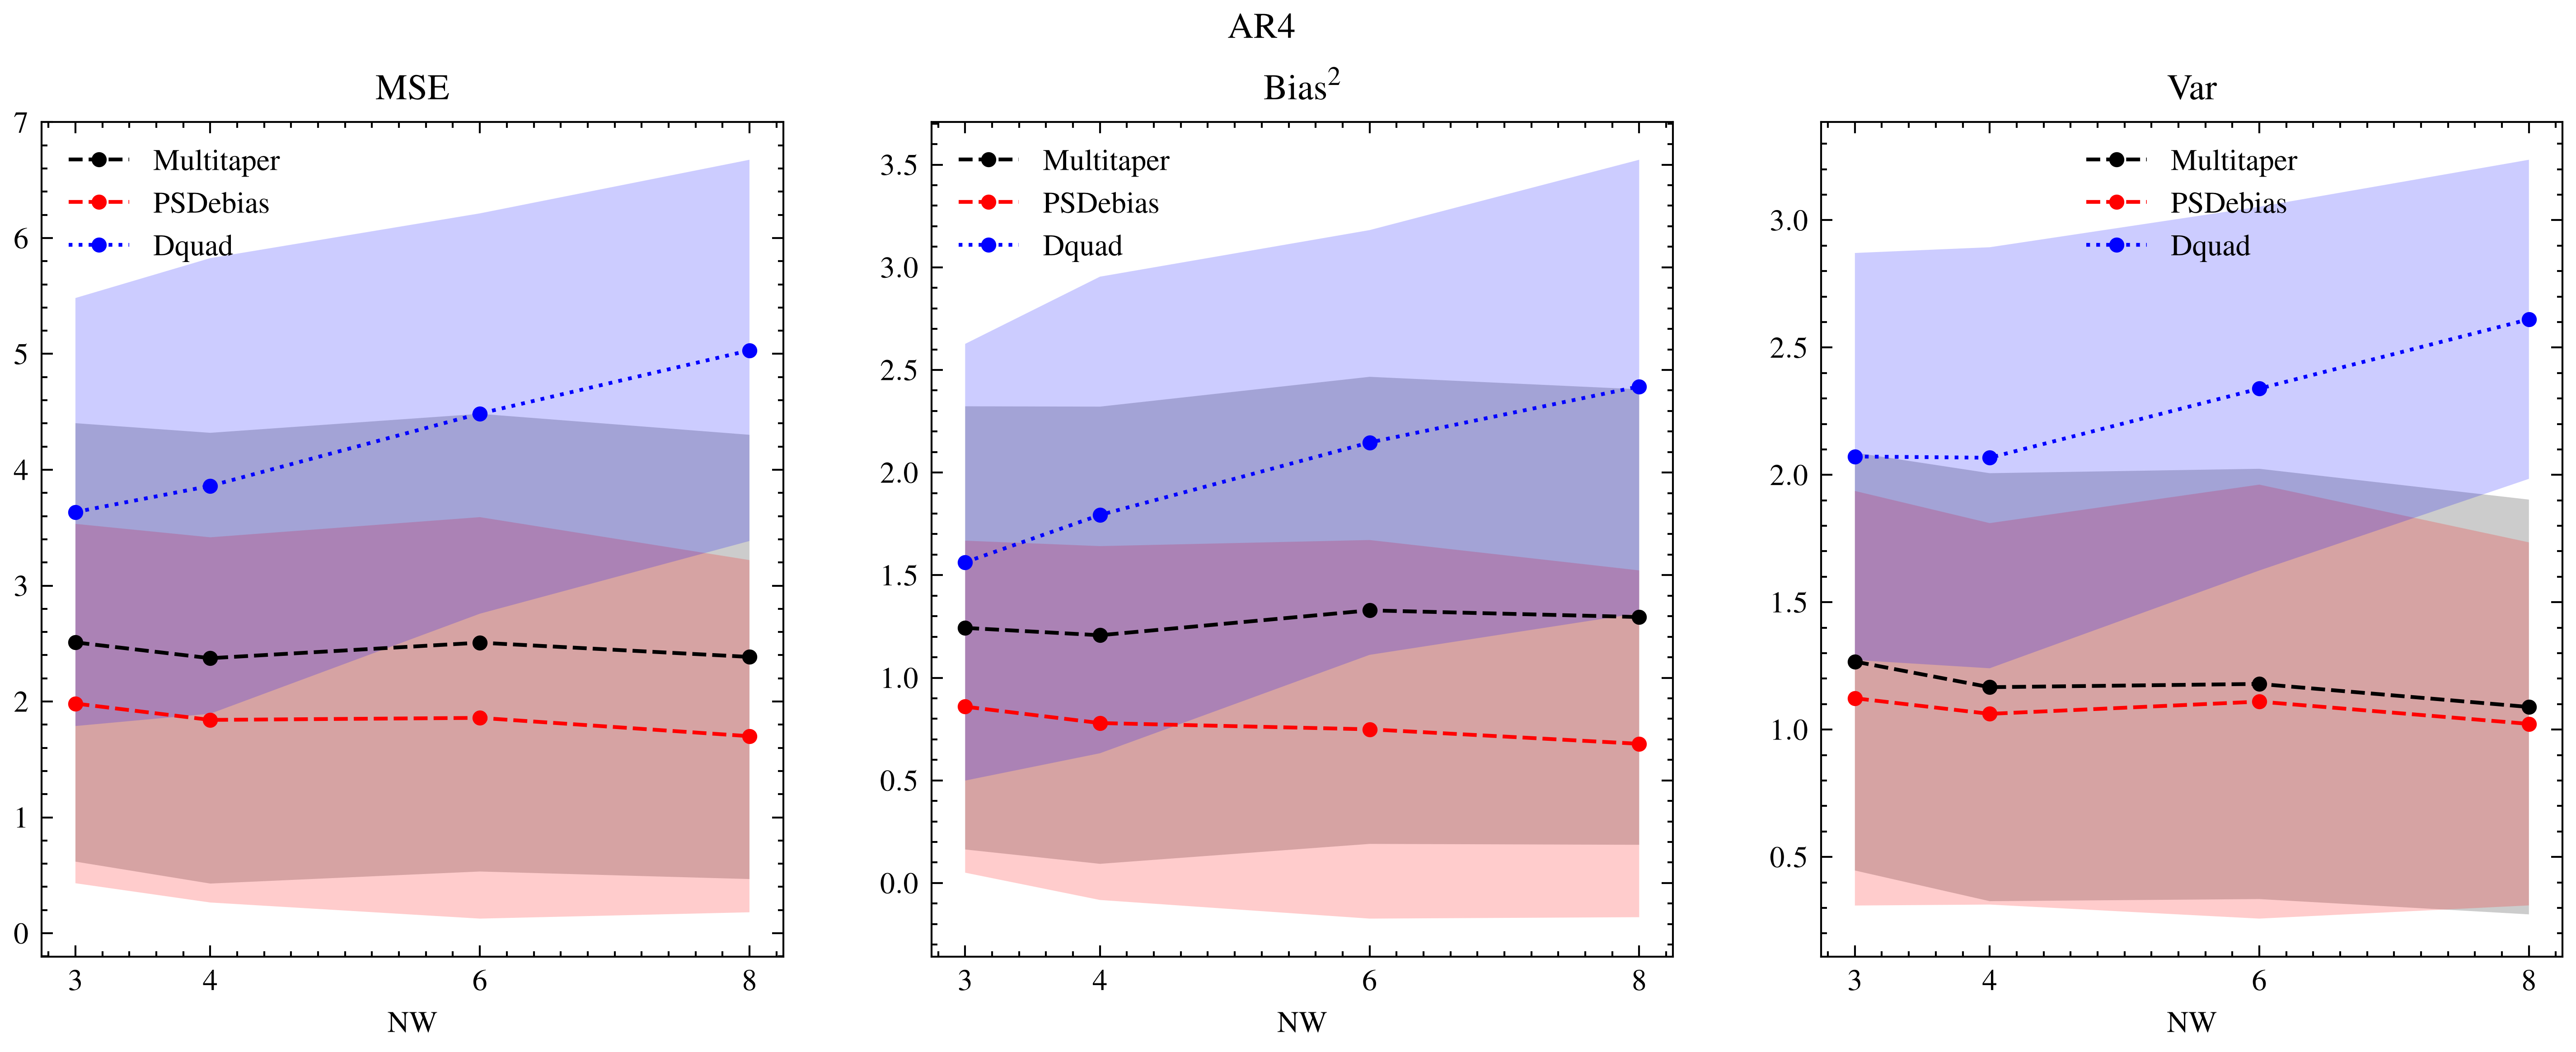

=== Multitaper / Matérn / debiasing ===
PSDebias:
  3: n=200/200, MSE: 0.84, Bias^2: 0.54, Var: 0.83
  4: n=200/200, MSE: 1.05, Bias^2: 0.06, Var: 1.14
  6: n=199/200, MSE: 1.51, Bias^2: 0.12, Var: 1.74
  8: n=200/200, MSE: 1.50, Bias^2: 0.15, Var: 1.82
Dquad:
  3: n=198/200, MSE: 1.00, Bias^2: 0.40, Var: 1.02
  4: n=200/200, MSE: 1.16, Bias^2: 0.06, Var: 1.25
  6: n=140/200, MSE: 1.86, Bias^2: 0.05, Var: 2.15
  8: n=21/200, MSE: 2.30, Bias^2: 0.00, Var: 2.87


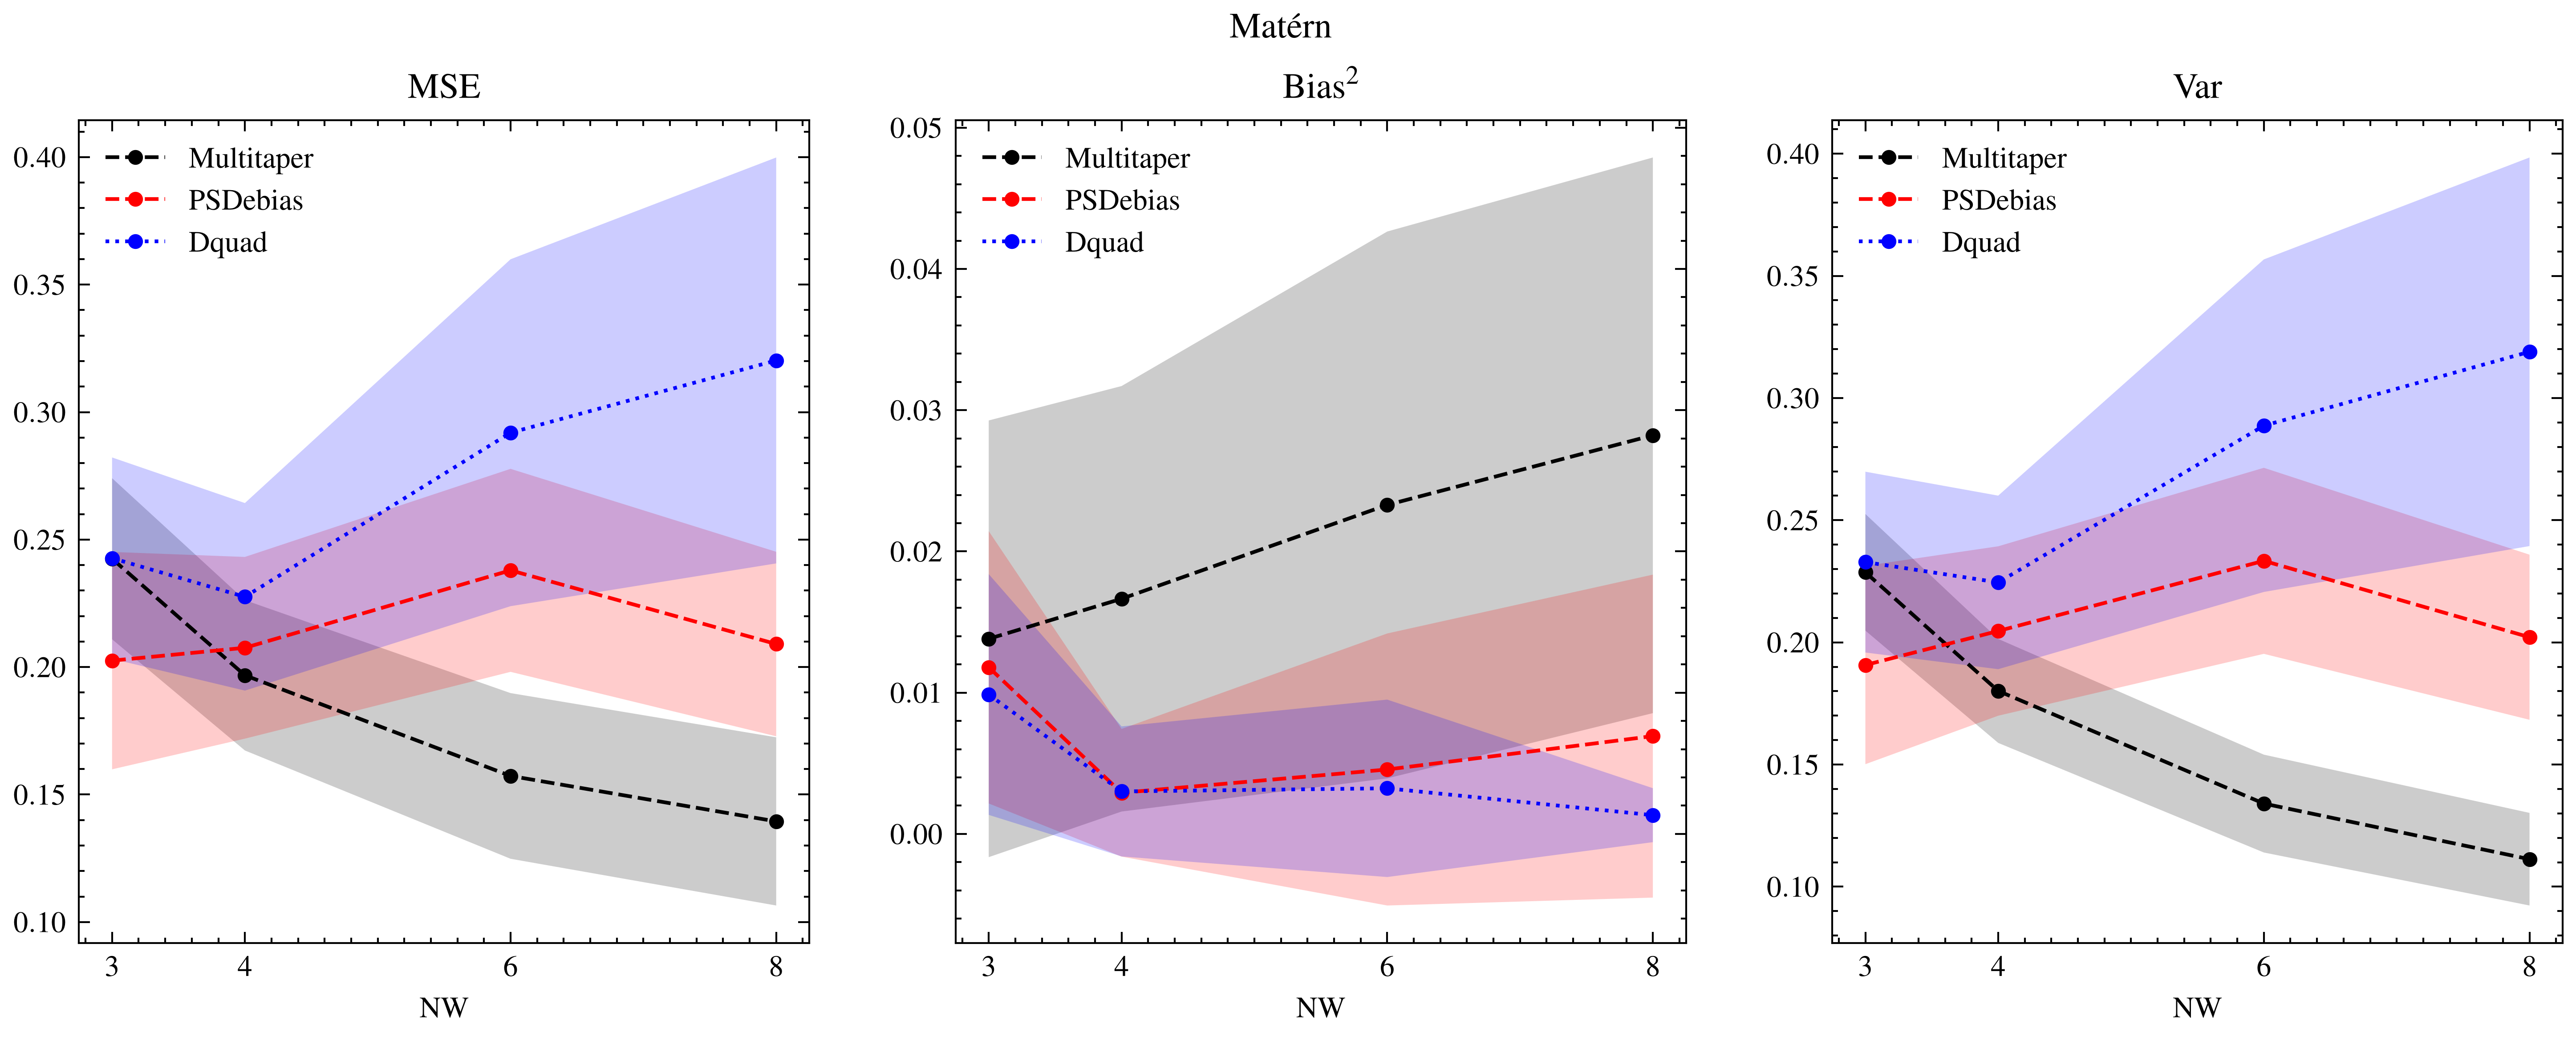

In [16]:
os.makedirs(f'{FIGS}/results', exist_ok=True)
results_store = {}

for method_name, cfg in METHODS.items():
    for arm, arm_slug in ARMS.items():
        for signal, scfg in SIGNALS.items():
            base_dir = f"{BASE}/{signal}_{arm}"
            if not os.path.isdir(f"{base_dir}/{cfg['sim_subdir']}"):
                continue
            file_ms = cfg['file_ms'][arm]
            display_ms = cfg['display_ms'][arm]

            results = load_results(cfg, file_ms, base_dir, signal)
            stats = compute_stats(results)
            results_store[(method_name, arm, signal)] = (results, stats)

            print(f"=== {method_name} / {scfg['title']} / {arm} ===")
            print_ratios(stats, display_ms)

            fig, ax = plot_results(display_ms, stats, label=method_name,
                                   xlabel=cfg['xlabel'],
                                   xticklabels=cfg['xticklabels'],
                                   fig_title=scfg['title'])
            fig.savefig(f"{FIGS}/results/{cfg['slug']}_{scfg['slug']}_{arm_slug}.pdf",
                        bbox_inches='tight')
            plt.show()
            plt.close(fig)

## Average rank across simulations

Ranks derived from the mean MSEs above: at every setting the raw estimator and
whichever debias / smoothing streams the arm produced are ranked by mean MSE,
then the ranks are averaged over the arm's settings. Streams within
`RANK_RTOL` = 2% of the best mean MSE at a setting score equal there and share
the mid-rank — PSDebias and wavelet thresholding land inside 1% of each other
on three of the smoothing panels, and calling that a win either way would be
reading noise. The nearest gaps the rule does *not* tie are 5.4% and 5.5%, so
anything from 1.5% to 5% clusters this data identically.

A setting where a stream lost every realisation is dropped for all streams, so
a panel can average over fewer than four settings — Dquad's `n=0/200` at
Lag-Window / AR4 / debiasing $\tau = 128$ is the only such case here.

The rank is MSE only, so it says nothing about *why* a stream loses: read the
Matérn / debiasing multitaper panel, where the raw estimator ranks best,
alongside the mesh-vs-bandwidth check above — its knot spacing is finer than
the identifiable bandwidth at every NW but 3.

=== Welch / AR4 / Debiasing ===
  Standard: 3.00, PSDebias: 1.00, Dquad: 2.00
=== Lag-Window / AR4 / Debiasing ===
  Standard: 3.00, PSDebias: 1.00, Dquad: 2.00
=== Multitaper / AR4 / Debiasing ===
  Standard: 2.00, PSDebias: 1.00, Dquad: 3.00
=== Welch / Matérn / Debiasing ===
  Standard: 3.00, PSDebias: 1.00, Dquad: 2.00
=== Lag-Window / Matérn / Debiasing ===
  Standard: 3.00, PSDebias: 1.00, Dquad: 2.00
=== Multitaper / Matérn / Debiasing ===
  Standard: 1.38, PSDebias: 1.75, Dquad: 2.88


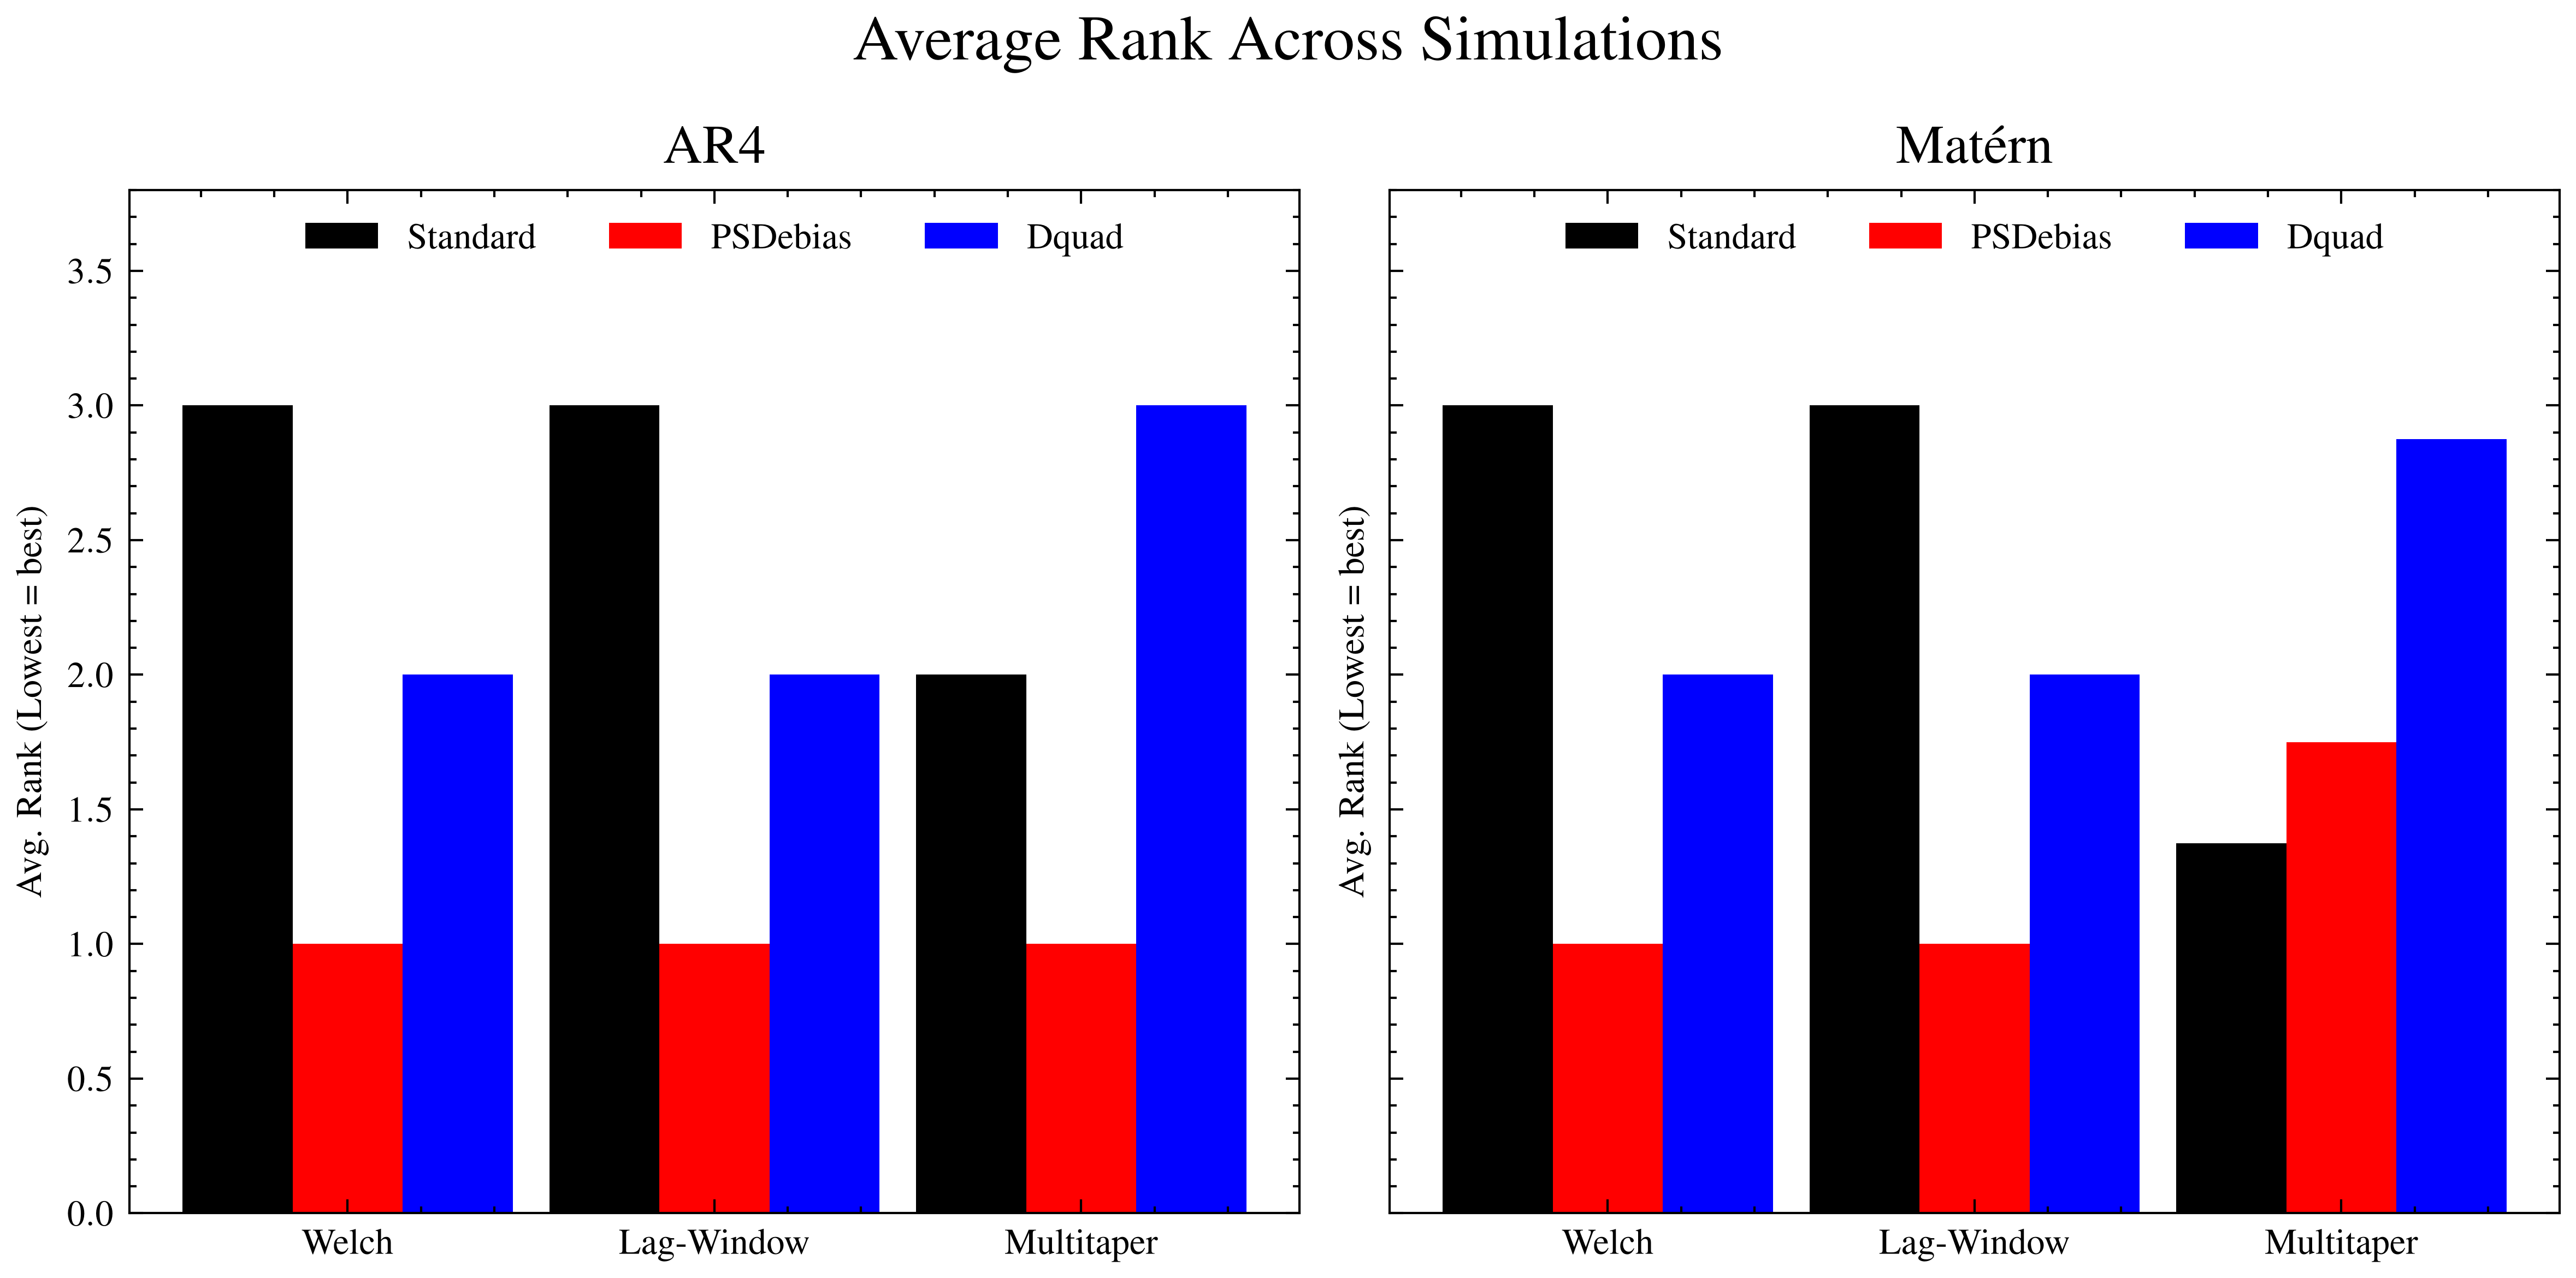

In [ ]:
RAW_LABEL = 'Standard'
ARM_TITLES = {'debiasing': 'Debiasing'}
RANK_RTOL = 0.02  # mean MSEs within 2% of the best count as the same score


def _tolerant_ranks(mse):
    """Ranks (1 = best) down one setting's mean MSEs, where a value within
    RANK_RTOL of its cluster's best is scored as tied with it and the tied
    streams share the mid-rank. Clusters compare against their best rather than
    the previous value, so a run of small steps cannot chain into one tie."""
    order = np.argsort(mse)
    clusters = np.zeros(len(mse), dtype=int)
    best = mse[order[0]]
    for prev, cur in zip(order, order[1:]):
        if mse[cur] > best * (1 + RANK_RTOL):
            clusters[cur] = clusters[prev] + 1
            best = mse[cur]
        else:
            clusters[cur] = clusters[prev]
    return sp.stats.rankdata(clusters)


def average_ranks(stats):
    """Average rank (1 = best) by mean MSE over an arm's settings, for the raw
    estimator and whichever streams the arm produced. Streams within RANK_RTOL
    of the best at a setting score equal there.

    A setting where any stream lost every realisation carries no mean MSE for
    it, so the setting is dropped for all streams — ranking it would hand the
    absent stream a last place it never earned on the same data."""
    streams = {RAW_LABEL: stats['value']}
    streams.update({label: stats[key] for key, label in STREAM_LABELS.items()
                    if stats.get(key) is not None})

    mse = np.array([[_safe_mean(s[:, 0]) for s in stream]
                    for stream in streams.values()])  # (n_streams, n_settings)
    mse = mse[:, ~np.isnan(mse).any(axis=0)]
    ranks = np.array([_tolerant_ranks(col) for col in mse.T]).mean(axis=0)
    return dict(zip(streams, ranks))




rank_tables = {arm: {scfg['title']: {} for scfg in SIGNALS.values()} for arm in ARMS}
for (method_name, arm, signal), (_, stats) in results_store.items():
    rank_tables[arm][SIGNALS[signal]['title']][method_name] = average_ranks(stats)

for arm, arm_title in ARM_TITLES.items():
    for title, methods in rank_tables[arm].items():
        for method_name, ranks in methods.items():
            print(f"=== {method_name} / {title} / {arm_title} ===")
            print('  ' + ', '.join(f'{k}: {v:.2f}' for k, v in ranks.items()))


def _plot_bars(ax, data, title):
    estimators = list(data.keys())
    all_methods = list(dict.fromkeys(m for est in data.values() for m in est))

    x = np.arange(len(estimators))
    n = len(all_methods)
    width = 0.9 / n

    for i, method in enumerate(all_methods):
        offsets = (i - n / 2 + 0.5) * width
        vals = [data[est].get(method, np.nan) for est in estimators]
        ax.bar(x + offsets, vals, width, label=method)

    ax.set_xticks(x)
    ax.set_xticklabels(estimators)
    ax.set_ylabel('Avg. Rank (Lowest = best)')
    ax.set_title(title,fontsize=12)
    # Every bar starts at rank 0, so an in-axes legend anywhere else sits on top
    # of one; the headroom set below keeps this strip clear.
    ax.legend(loc='upper center', ncol=n)


fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
fig.suptitle('Average Rank Across Simulations', fontsize=14)

for row, (arm, arm_title) in enumerate(ARM_TITLES.items()):
    for col, scfg in enumerate(SIGNALS.values()):
        _plot_bars(axes[col], rank_tables[arm][scfg['title']],
                   f"{scfg['title']}")

worst = max(r for panels in rank_tables.values() for panel in panels.values()
            for ranks in panel.values() for r in ranks.values())
axes[0].set_ylim(0, worst + 0.8)  # strip above the tallest bar for the legends

plt.tight_layout()
fig.savefig(f'{FIGS}/bar_results.pdf', bbox_inches='tight')